In [ ]:
#Empecemos en primer lugar por importar el archivo dsv en formato lectura.
from google.colab import drive
drive.mount("/content/drive")
# Para una mayor eficiencia en el analisis de datos y la deteccion de tipos utilizaremos la libreria pandas.
import pandas as pd
# A continuacion importamos el archivo en formato lectura.
df=pd.read_csv('/content/drive/MyDrive/Proyectos Nexeus/ecoenergy-consumption-data.csv')

#Procedemos con  la revision de la estructura y tipos de datos, en caso de que haya que hacer algun cambio.
print("Informacion general del dataset")
df. info()

#Comprovacion de la existencia de valores vacios o nulos.
print("Valores nulos")
df.isnull().sum()

#Visualizacion de los datos.
print("Primeros 5 datos")
df.head()

Mounted at /content/drive
Informacion general del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   client_id                    10000 non-null  int64  
 1   client_name                  10000 non-null  object 
 2   region                       10000 non-null  object 
 3   contract_type                10000 non-null  object 
 4   consumption_kwh              10000 non-null  int64  
 5   billing_date                 10000 non-null  object 
 6   co2_emissions                10000 non-null  float64
 7   cost_per_kwh                 10000 non-null  float64
 8   total_cost                   10000 non-null  float64
 9   renewable_energy_percentage  10000 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB
Valores nulos
Primeros 5 datos


,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
0,1,"Hood, Cooper and Burke",Centro,Residencial,3423,2024-03-23,276.74,0.13,444.99,89
1,2,"Hamilton, White and Smith",Este,Comercial,7714,2024-08-05,1805.79,0.15,1157.10,37
2,3,Keith Group,Sur,Residencial,3745,2024-02-04,726.34,0.14,524.30,69
3,4,Jackson-Strong,Oeste,Comercial,8151,2024-06-21,130.05,0.18,1467.18,29
4,5,"Coleman, Ayala and Sullivan",Este,Comercial,3137,2024-02-16,961.67,0.24,752.88,50


In [ ]:
# Convertimos billing_date a un formato fecha
df["billing_date"] = pd.to_datetime(df["billing_date"])

# Verificación de duplicados (aquí estaba el error: usamos duplicated)
print(f"Duplicados encontrados: {df.duplicated().sum()}")

# Comprobación de valores negativos
print(f"Valores negativos en consumo: {(df['consumption_kwh'] < 0).sum()}")
print(f"Valores negativos en emisiones: {(df['co2_emissions'] < 0).sum()}")

Duplicados encontrados: 0
Valores negativos en consumo: 0
Valores negativos en emisiones: 0


In [ ]:
# Estadísticas descriptivas de las variables clave
print("--- Resumen Estadístico ---")
display(df[['consumption_kwh', 'co2_emissions', 'total_cost', 'renewable_energy_percentage']].describe())

# Análisis de regiones: ¿Dónde se consume más energía?
print("\n--- Consumo promedio por región ---")
display(df.groupby('region')['consumption_kwh'].mean())

--- Resumen Estadístico ---


,consumption_kwh,co2_emissions,total_cost,renewable_energy_percentage
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,5051.087500,1019.702840,886.023571,49.113500
std,2867.303781,563.427136,565.830649,28.812154
min,100.000000,50.040000,10.000000,0.000000
25%,2588.000000,536.412500,418.455000,24.000000
50%,5032.500000,1020.240000,818.625000,49.000000
75%,7542.250000,1510.840000,1276.492500,74.000000
max,9999.000000,1999.940000,2497.500000,99.000000



--- Consumo promedio por región ---


,consumption_kwh
region,
Centro,5027.341176
Este,5014.982544
Norte,5114.715400
Oeste,5018.580560
Sur,5076.860697


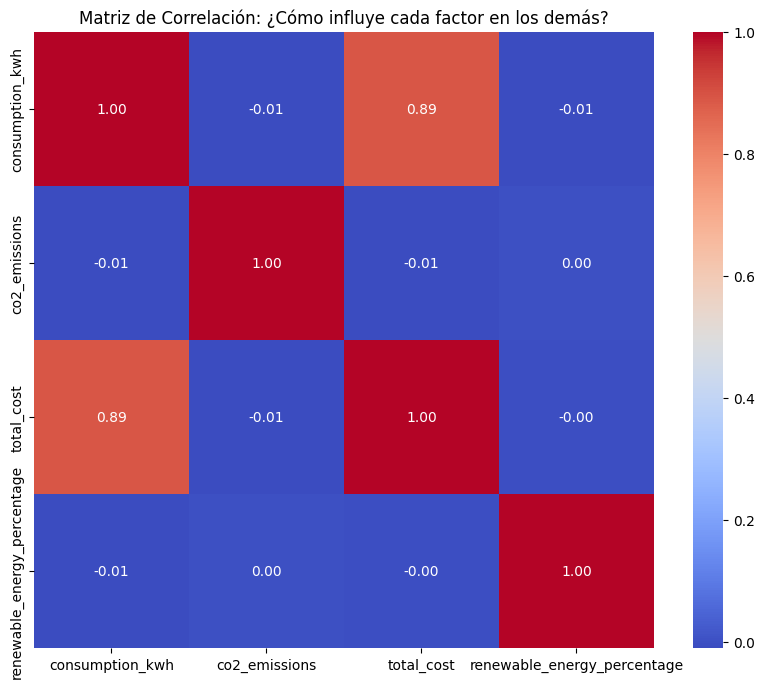

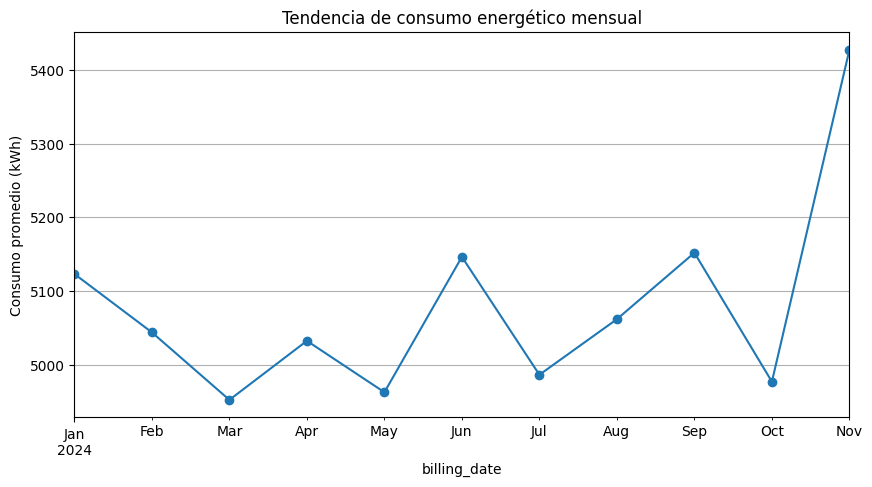

In [ ]:
# Importamos las herramientas de dibujo: Matplotlib para crear los gráficos desde cero
# y Seaborn para aplicarles estilos profesionales y modernos automáticamente.
import matplotlib.pyplot as plt
import seaborn as sns

# Aquí calculamos cómo se relacionan las variables entre sí.
# El método .corr() mide si, cuando una variable sube, otra también lo hace.
# Seleccionamos solo las columnas numéricas que nos interesan para este estudio.
correlacion = df[['consumption_kwh', 'co2_emissions', 'total_cost', 'renewable_energy_percentage']].corr()

# Configuramos el tamaño del recuadro del gráfico para que sea cómodo de leer.
plt.figure(figsize=(10, 8))

# El 'heatmap' (mapa de calor) pinta una tabla de colores:
# Los colores cálidos indican una relación directa (si uno sube, el otro también).
# 'annot=True' muestra los números exactos dentro de cada cuadro.
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: ¿Cómo influye cada factor en los demás?")
plt.show()

# Para analizar tendencias, primero debemos decirle al sistema qué columna es la fecha.
# Al convertirla en el 'índice', Pandas entenderá que los datos están ordenados en el tiempo.
df.set_index('billing_date', inplace=True)

# Aquí agrupamos todos los datos diarios en "cubetas" mensuales (resample 'ME').
# Luego, calculamos el promedio de cada mes para tener una visión general clara.
consumo_mensual = df['consumption_kwh'].resample('ME').mean()

# Creamos el gráfico de líneas para visualizar la evolución del consumo.
plt.figure(figsize=(10, 5))
# Dibujamos los puntos promediados y los unimos con una línea para ver la tendencia.
consumo_mensual.plot(marker='o')
plt.title('Tendencia de consumo energético mensual')
plt.ylabel('Consumo promedio (kWh)')
plt.grid(True) # Añadimos una cuadrícula para facilitar la lectura visual.
plt.show()


In [ ]:
import os

# Guardamos el dataset ya limpio y verificado como un nuevo archivo
# Esto es lo que conectaremos a Google Looker Studio
ruta_salida = '/content/drive/MyDrive/PPersonales/Limpieza de datos/ecoenergy_data_clean.csv'

# Asegurarse de que el directorio exista
os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

df.to_csv(ruta_salida, index=True)

print(f"¡Dataset listo! Se ha guardado correctamente en: {ruta_salida}")

¡Dataset listo! Se ha guardado correctamente en: /content/drive/MyDrive/PPersonales/Limpieza de datos/ecoenergy_data_clean.csv
